## Linear Regression Baseline

Taken from WeatherBench github

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import seaborn as sns
import pickle
from score import *
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from tqdm import tqdm_notebook as tqdm

In [2]:
def to_pickle(obj, fn):
    with open(fn, 'wb') as f:
        pickle.dump(obj, f)
def read_pickle(fn):
    with open(fn, 'rb') as f:
        return pickle.load(f)

## Load and prepare data for training
First up, we need to load and prepare the data so that we can feed it into our linear regression model.

In [ ]:
z500 = xr.open_mfdataset('data/5.625deg/geopotential_500/*.nc', combine='by_coords')
z500_train = z500.sel(time=slice('1979', '2016'))
z500_test = z500.sel(time=slice('2017', '2018')) # 2017-2018 data

In [4]:
z500

<xarray.Dataset> Size: 3GB
Dimensions:  (time: 350640, lat: 32, lon: 64)
Coordinates:
    level    int32 4B 500
  * lon      (lon) float64 512B 0.0 5.625 11.25 16.88 ... 343.1 348.8 354.4
  * lat      (lat) float64 256B -87.19 -81.56 -75.94 ... 75.94 81.56 87.19
  * time     (time) datetime64[ns] 3MB 1979-01-01 ... 2018-12-31T23:00:00
Data variables:
    z        (time, lat, lon) float32 3GB dask.array<chunksize=(8760, 32, 64), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    history:      2019-11-10 20:33:23 GMT by grib_to_netcdf-2.14.0: /opt/ecmw...

In [5]:
z500_test

<xarray.Dataset> Size: 144MB
Dimensions:  (time: 17520, lat: 32, lon: 64)
Coordinates:
    level    int32 4B 500
  * lon      (lon) float64 512B 0.0 5.625 11.25 16.88 ... 343.1 348.8 354.4
  * lat      (lat) float64 256B -87.19 -81.56 -75.94 ... 75.94 81.56 87.19
  * time     (time) datetime64[ns] 140kB 2017-01-01 ... 2018-12-31T23:00:00
Data variables:
    z        (time, lat, lon) float32 144MB dask.array<chunksize=(8760, 32, 64), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    history:      2019-11-10 20:33:23 GMT by grib_to_netcdf-2.14.0: /opt/ecmw...

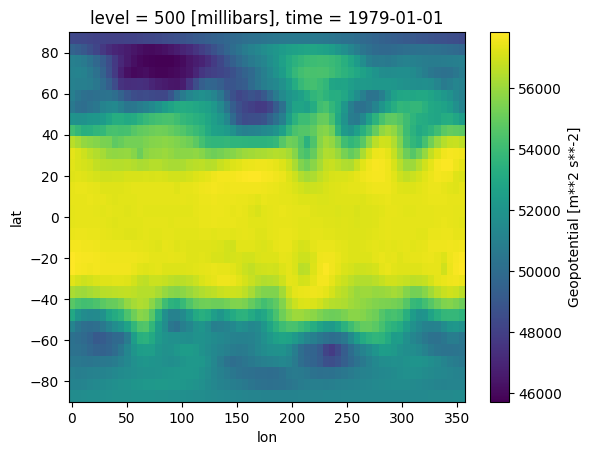

In [6]:
# Plot an example
z500.z.isel(time=0).plot();

In [7]:
data_mean = z500_train.mean().load()
data_std = z500_train.std().load()

In [8]:
# Normalize datasets
data_train = (z500_train - data_mean) / data_std
data_test = (z500_test - data_mean) / data_std

In [9]:
data_train, data_test

(<xarray.Dataset> Size: 3GB
 Dimensions:  (lon: 64, lat: 32, time: 333120)
 Coordinates:
     level    int32 4B 500
   * lon      (lon) float64 512B 0.0 5.625 11.25 16.88 ... 343.1 348.8 354.4
   * lat      (lat) float64 256B -87.19 -81.56 -75.94 ... 75.94 81.56 87.19
   * time     (time) datetime64[ns] 3MB 1979-01-01 ... 2016-12-31T23:00:00
 Data variables:
     z        (time, lat, lon) float32 3GB dask.array<chunksize=(8760, 32, 64), meta=np.ndarray>,
 <xarray.Dataset> Size: 144MB
 Dimensions:  (lon: 64, lat: 32, time: 17520)
 Coordinates:
     level    int32 4B 500
   * lon      (lon) float64 512B 0.0 5.625 11.25 16.88 ... 343.1 348.8 354.4
   * lat      (lat) float64 256B -87.19 -81.56 -75.94 ... 75.94 81.56 87.19
   * time     (time) datetime64[ns] 140kB 2017-01-01 ... 2018-12-31T23:00:00
 Data variables:
     z        (time, lat, lon) float32 144MB dask.array<chunksize=(8760, 32, 64), meta=np.ndarray>)

In [10]:
_, nlat, nlon = data_train.z.shape; nlat, nlon

(32, 64)

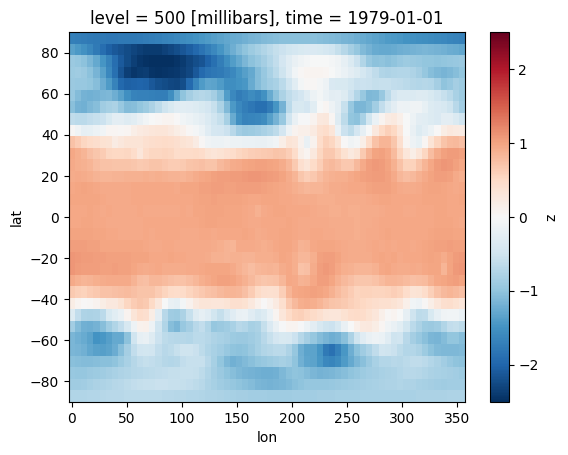

In [11]:
data_train.z.isel(time=0).plot()

In [12]:
def create_training_data(data, lead_time_h, return_valid_time=False):
    """Function to split input and output by lead time."""
    X = data.isel(time=slice(0, -lead_time_h))
    y = data.isel(time=slice(lead_time_h, None))
    valid_time = y.time
    if return_valid_time:
        return X.values.reshape(-1, nlat*nlon), y.values.reshape(-1, nlat*nlon), valid_time
    else:
        return X.values.reshape(-1, nlat*nlon), y.values.reshape(-1, nlat*nlon)

In [13]:
def train_lr(lead_time_h, input_vars, output_vars, data_subsample=1):
    """Create data, train a linear regression and return the predictions."""
    X_train, y_train, X_test, y_test = [], [], [], []
    for v in input_vars:
        X, y = create_training_data(
            data_train[v],
            lead_time_h
        )
        
        X_train.append(X)
        if v in output_vars: y_train.append(y)
        X, y, valid_time = create_training_data(data_test[v], lead_time_h, return_valid_time=True)
        X_test.append(X)
        if v in output_vars: y_test.append(y)
    X_train, y_train, X_test, y_test = [np.concatenate(d, 1) for d in [X_train, y_train, X_test, y_test]]
    
    X_train = X_train[::data_subsample]
    y_train = y_train[::data_subsample]
    
    lr = LinearRegression(n_jobs=16)
    lr.fit(X_train, y_train)
    
    mse_train = mean_squared_error(y_train, lr.predict(X_train))
    mse_test = mean_squared_error(y_test, lr.predict(X_test))
    print(f'Train MSE = {mse_train}'); print(f'Test MSE = {mse_test}')
    preds = lr.predict(X_test).reshape((-1, len(output_vars), nlat, nlon))
    
    fcs = []
    for i, v in enumerate(output_vars):
        fc = xr.DataArray(
            preds[:, i] * data_std[v].values + data_mean[v].values, 
            dims=['time', 'lat', 'lon'],
            coords={
                'time': valid_time,
                'lat': data_train.lat,
                'lon': data_train.lon
            },
            name=v
        )
        fcs.append(fc)
    return xr.merge(fcs), lr   

Train the model to predict the geopotential at 3 days lead time.

In [14]:
experiments = [
    [['z'], ['z']],
]

# we only take every 5th time step which gives almost the same results (<0.5% difference)
data_subsample = 5
lead_time = 3*24
preds = []
models = []

PREDDIR = ''

for n, (i, o) in enumerate(experiments):
    print(f'{n}: Input variables = {i}; output variables = {o}')
    p, m = train_lr(lead_time, input_vars=i, output_vars=o, data_subsample=data_subsample)
    preds.append(p); models.append(m)
    r = compute_weighted_rmse(p, z500_test).compute()
    print('; '.join([f'{v} = {r[v].values}' for v in r]) + '\n')

0: Input variables = ['z']; output variables = ['z']
Train MSE = 0.05164600908756256
Test MSE = 0.054345402866601944
z = 672.5770468533665



## Iterative Forecasts

In [ ]:
def create_iterative_fc(state, model, lead_time_h=6, max_lead_time_h=5*24):
    max_fc_steps = max_lead_time_h // lead_time_h
    fcs_z500 = []
    for fc_step in tqdm(range(max_fc_steps)):
        state = model.predict(state)
        fc_z500 = state[:, :nlat*nlon].copy() * data_std.z.values + data_mean.z.values
        fc_z500 = fc_z500.reshape((-1, nlat, nlon))
        fcs_z500.append(fc_z500)

    return [xr.DataArray(
        np.array(fcs), 
        dims=['lead_time', 'time', 'lat', 'lon'],
        coords={
            'lead_time': np.arange(lead_time_h, max_lead_time_h + lead_time_h, lead_time_h),
            'time': z500_test.time,
            'lat': z500_test.lat,
            'lon': z500_test.lon
        }
    ) for fcs in [fcs_z500]]

In [84]:
state = data_test.z.values.reshape(-1, nlat*nlon)

In [85]:
fc_z500_6h_iter = create_iterative_fc(state, m)

C:\Users\sunny\AppData\Local\Temp\ipykernel_37612\2753150852.py:4: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for fc_step in tqdm(range(max_fc_steps)):


  0%|          | 0/20 [00:00<?, ?it/s]

In [87]:
fc_z500_6h_iter

[<xarray.DataArray (lead_time: 20, time: 17520, lat: 32, lon: 64)> Size: 3GB
 array([[[[50368.52 , 50377.203, 50386.61 , ..., 50355.766, 50357.715,
           50362.12 ],
          [50365.19 , 50447.066, 50526.973, ..., 50194.598, 50234.562,
           50292.254],
          [50507.12 , 50663.85 , 50789.863, ..., 50066.61 , 50192.68 ,
           50341.81 ],
          ...,
          [50719.055, 50631.156, 50520.215, ..., 50952.145, 50877.   ,
           50795.12 ],
          [50518.242, 50504.746, 50485.53 , ..., 50519.484, 50524.41 ,
           50523.836],
          [50591.062, 50600.87 , 50612.61 , ..., 50556.727, 50567.996,
           50579.234]],
 
         [[50390.   , 50398.906, 50408.676, ..., 50376.684, 50378.82 ,
           50383.383],
          [50390.23 , 50472.797, 50553.062, ..., 50216.773, 50257.973,
           50316.586],
          [50539.207, 50695.04 , 50819.08 , ..., 50093.742, 50222.055,
           50372.824],
 ...
          [51641.94 , 51645.656, 51644.855, ..., 51632

In [88]:
fc_iter = xr.Dataset({'z': fc_z500_6h_iter[0]})

In [89]:
fc_iter

<xarray.Dataset> Size: 3GB
Dimensions:    (lead_time: 20, time: 17520, lat: 32, lon: 64)
Coordinates:
  * lead_time  (lead_time) int64 160B 6 12 18 24 30 36 ... 90 96 102 108 114 120
  * time       (time) datetime64[ns] 140kB 2017-01-01 ... 2018-12-31T23:00:00
  * lat        (lat) float64 256B -87.19 -81.56 -75.94 ... 75.94 81.56 87.19
  * lon        (lon) float64 512B 0.0 5.625 11.25 16.88 ... 343.1 348.8 354.4
Data variables:
    z          (lead_time, time, lat, lon) float32 3GB 5.037e+04 ... 5.097e+04

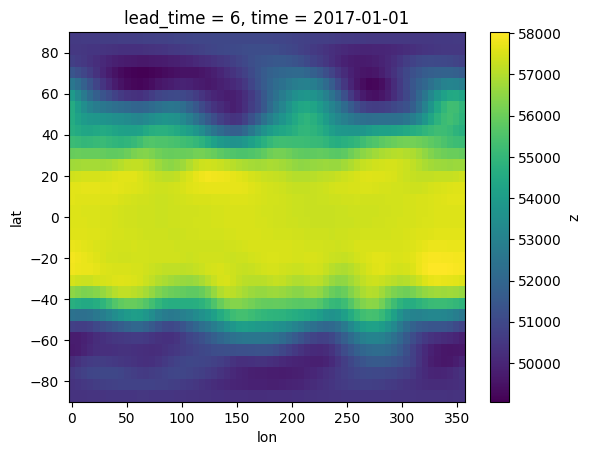

In [100]:
fc_iter.z.isel(lead_time=0, time=0).plot()

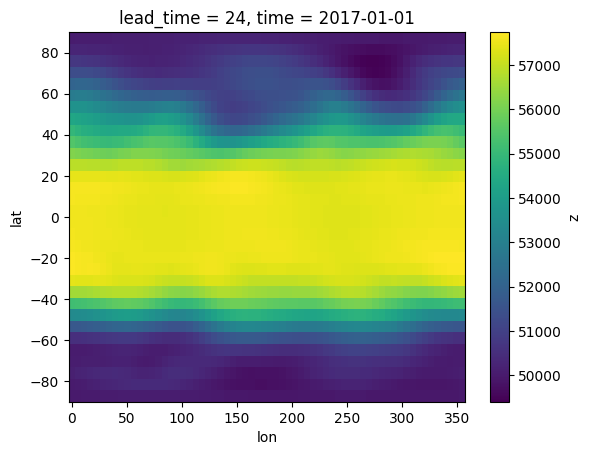

In [101]:
fc_iter.z.isel(lead_time=3, time=0).plot()